# GPT-2 Probing and Valence Analysis

**Phase 2 + Phase 4:** Race/ethnicity activation probing (all three pairwise comparisons) and full-vocabulary valence analysis for GPT-2.

**Hardware:** M4 Mac Mini or A100  
**Runtime:** ~15 minutes

**Run all cells top to bottom.**

**Outputs:** `white_encoding_results.pkl`, `white_encoding_probe_results.csv`, `white_encoding_valence_layer6.png`, `white_black_valence_by_layer.png`


In [1]:
# Cell 1 — setup (skip if already done this session)
!pip install -q numpy==1.26.4
!pip install -q transformer_lens

import json, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformer_lens import HookedTransformer
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR = f'/content/drive/MyDrive/ID-UTH-repo/activations'
OUTPUT_DIR = f'/content/drive/MyDrive/ID-UTH-repo/white_encoding'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = 'cuda'
GPT2_LAYERS = [3, 6, 9, 11]
print('Ready')

Ready


In [2]:
# Cell 2 — load BBQ and find group indices
dataset = load_dataset('Elfsong/BBQ', split='race_ethnicity')
race_df = dataset.to_pandas()
race_ambig = race_df[race_df['context_condition'] == 'ambig'].reset_index(drop=True)

group_indices = {'White': [], 'Black': [], 'Hispanic': []}
for i, row in race_ambig.iterrows():
    context = row['context']
    if 'White' in context and 'Non-white' not in context:
        group_indices['White'].append(i)
    elif 'Black' in context and 'African American' not in context:
        group_indices['Black'].append(i)
    elif 'Hispanic' in context:
        group_indices['Hispanic'].append(i)

for group, indices in group_indices.items():
    print(f'{group}: {len(indices)} prompts')

README.md: 0.00B [00:00, ?B/s]

data/age-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/disability_status-00000-of-00001.pa(…):   0%|          | 0.00/85.2k [00:00<?, ?B/s]

data/gender_identity-00000-of-00001.parq(…):   0%|          | 0.00/217k [00:00<?, ?B/s]

data/nationality-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

...

Generating race_x_ses split:   0%|          | 0/11160 [00:00<?, ? examples/s]

Generating religion split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating ses split:   0%|          | 0/6864 [00:00<?, ? examples/s]

Generating sexual_orientation split:   0%|          | 0/864 [00:00<?, ? examples/s]

White: 60 prompts
Black: 252 prompts
Hispanic: 136 prompts


In [3]:
# Cell 3 — load GPT-2
print('Loading GPT-2...')
model = HookedTransformer.from_pretrained('gpt2', device=DEVICE)
model.eval()
print('Loaded.')

Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Loaded.


In [4]:
# Cell 4 — extraction function
def format_prompt(row):
    return (
        f"Context: {row['context']}\n"
        f"Question: {row['question']}\n"
        f"A) {row['ans0']}\n"
        f"B) {row['ans1']}\n"
        f"C) {row['ans2']}\n"
        f"Answer:"
    )

def extract_token_activations(prompt, model, target_word, layers):
    tokens = model.to_tokens(prompt)
    token_strings = [model.to_string(tokens[0][i]) for i in range(tokens.shape[1])]
    target_pos = None
    for i, tok in enumerate(token_strings):
        if target_word.strip() in tok.strip():
            target_pos = i
            break
    if target_pos is None:
        return None, None
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    activations = {}
    for layer in layers:
        activations[layer] = cache[f'blocks.{layer}.hook_resid_post'][
            0, target_pos, :].detach().cpu().numpy()
    return activations, target_pos

print('Functions defined.')

Functions defined.


In [5]:
# Cell 5 — extract activations for all three groups
N_PER_GROUP = 48  # match White sample size

group_records = {}

for group, target_word in [('White', 'White'), ('Black', 'Black'), ('Hispanic', 'Hispanic')]:
    records = []
    for i in group_indices[group][:N_PER_GROUP * 2]:  # oversample to account for misses
        row = race_ambig.iloc[i]
        prompt = format_prompt(row)
        acts, pos = extract_token_activations(prompt, model, target_word, GPT2_LAYERS)
        if acts is not None:
            records.append({
                'demo_group': group,
                **{f'layer_{l}': acts[l] for l in GPT2_LAYERS}
            })
        if len(records) >= N_PER_GROUP:
            break
    group_records[group] = records
    print(f'{group}: {len(records)} records extracted')

White: 48 records extracted
Black: 48 records extracted
Hispanic: 48 records extracted


In [6]:
# Cell 6 — probe: all three pairwise comparisons
def probe_cv(X, y, seed=42):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000, random_state=seed)
    scores = cross_val_score(clf, scaler.fit_transform(X), y, cv=cv, scoring='accuracy')
    return scores.mean(), scores.std()

comparisons = [
    ('White', 'Black'),
    ('White', 'Hispanic'),
    ('Hispanic', 'Black'),  # replication of existing result
]

print('Pairwise probe results (5-fold CV, chance = 50%)')
print()
probe_results = []

for group_a, group_b in comparisons:
    recs_a = group_records[group_a]
    recs_b = group_records[group_b]
    min_n = min(len(recs_a), len(recs_b))
    combined = recs_a[:min_n] + recs_b[:min_n]

    print(f'{group_a} vs {group_b} (n={min_n*2}):')
    for layer in GPT2_LAYERS:
        X = np.array([r[f'layer_{layer}'] for r in combined])
        y = np.array([r['demo_group'] for r in combined])
        mean, std = probe_cv(X, y)
        probe_results.append({'comparison': f'{group_a} vs {group_b}',
                               'layer': layer, 'accuracy': round(mean, 4),
                               'std': round(std, 4)})
        print(f'  Layer {layer}: {mean:.1%} ± {std:.1%}')
    print()

Pairwise probe results (5-fold CV, chance = 50%)

White vs Black (n=96):
  Layer 3: 100.0% ± 0.0%
  Layer 6: 100.0% ± 0.0%
  Layer 9: 100.0% ± 0.0%
  Layer 11: 100.0% ± 0.0%

White vs Hispanic (n=96):
  Layer 3: 100.0% ± 0.0%
  Layer 6: 100.0% ± 0.0%
  Layer 9: 100.0% ± 0.0%
  Layer 11: 100.0% ± 0.0%

Hispanic vs Black (n=96):
  Layer 3: 100.0% ± 0.0%
  Layer 6: 100.0% ± 0.0%
  Layer 9: 100.0% ± 0.0%
  Layer 11: 100.0% ± 0.0%



In [7]:
# Cell 7 — get W_E for valence analysis
W_E = model.embed.W_E.detach().cpu().numpy()  # (50257, 768)
tokenizer = model.tokenizer
vocab = [tokenizer.decode([i]).strip() for i in range(W_E.shape[0])]
print(f'W_E shape: {W_E.shape}')

W_E shape: (50257, 768)


In [8]:
# Cell 8 — valence analysis: all three directions
def dom_direction(acts_a, acts_b, layer):
    vecs_a = np.array([r[f'layer_{layer}'] for r in acts_a])
    vecs_b = np.array([r[f'layer_{layer}'] for r in acts_b])
    direction = vecs_a.mean(axis=0) - vecs_b.mean(axis=0)
    return direction / (np.linalg.norm(direction) + 1e-8)

def project_vocab(direction, W_E, vocab, top_k=10):
    norms = np.linalg.norm(W_E, axis=1, keepdims=True) + 1e-8
    scores = (W_E / norms) @ direction
    top_idx = np.argsort(scores)[::-1][:top_k]
    bot_idx = np.argsort(scores)[:top_k]
    return [(vocab[i], float(scores[i])) for i in top_idx], \
           [(vocab[i], float(scores[i])) for i in bot_idx]

# Three directions: White-Black, White-Hispanic, Hispanic-Black
directions = {
    'White_minus_Black':    ('White', 'Black'),
    'White_minus_Hispanic': ('White', 'Hispanic'),
    'Hispanic_minus_Black': ('Hispanic', 'Black'),
}

valence_results = {}
for direction_name, (group_a, group_b) in directions.items():
    valence_results[direction_name] = {}
    print(f'\n{direction_name}:')
    for layer in GPT2_LAYERS:
        top, bot = project_vocab(
            dom_direction(group_records[group_a], group_records[group_b], layer),
            W_E, vocab, top_k=10
        )
        valence_results[direction_name][layer] = {'top': top, 'bottom': bot}
        print(f'  Layer {layer}: {group_a} pole = {[t for t,s in top[:5]]} | '
              f'{group_b} pole = {[t for t,s in bot[:5]]}')


White_minus_Black:
  Layer 3: White pole = ['rotein', 'aukee', 'ghai', 'Poo', 'ween'] | Black pole = ['black', 'suit', 'Internet', 's', 'Comp']
  Layer 6: White pole = ['aukee', 'bilt', 'State', 'insula', 'ablishment'] | Black pole = ['any', 'strap', 'smith', 'ened', 'trace']
  Layer 9: White pole = ['bilt', 'ographically', 'ocol', 'ghai', 'insula'] | Black pole = ['smith', 'tie', 'tr', 'ened', 'black']
  Layer 11: White pole = ['House', '.', 'post', '(', ','] | Black pole = ['feet', 'rahim', 'Lives', 'protester', 'smith']

White_minus_Hispanic:
  Layer 3: White pole = ['horn', 'Plains', 'horse', 'Outer', 'haven'] | Hispanic pole = ['ity', 'specialty', 'seasoning', 'joints', 'to']
  Layer 6: White pole = ['Plains', 'hurst', 'haven', 'house', 'horse'] | Hispanic pole = ['ity', 'detention', 'ities', 'ITIES', 'joints']
  Layer 9: White pole = ['Plains', 'hurst', 'horse', 'power', 'House'] | Hispanic pole = ['restaurant', 'ity', 'ANS', 'delegation', 'Uri']
  Layer 11: White pole = ['Plain

Saved: /content/drive/MyDrive/ID-UTH-repo/white_encoding/white_encoding_valence_layer6.png


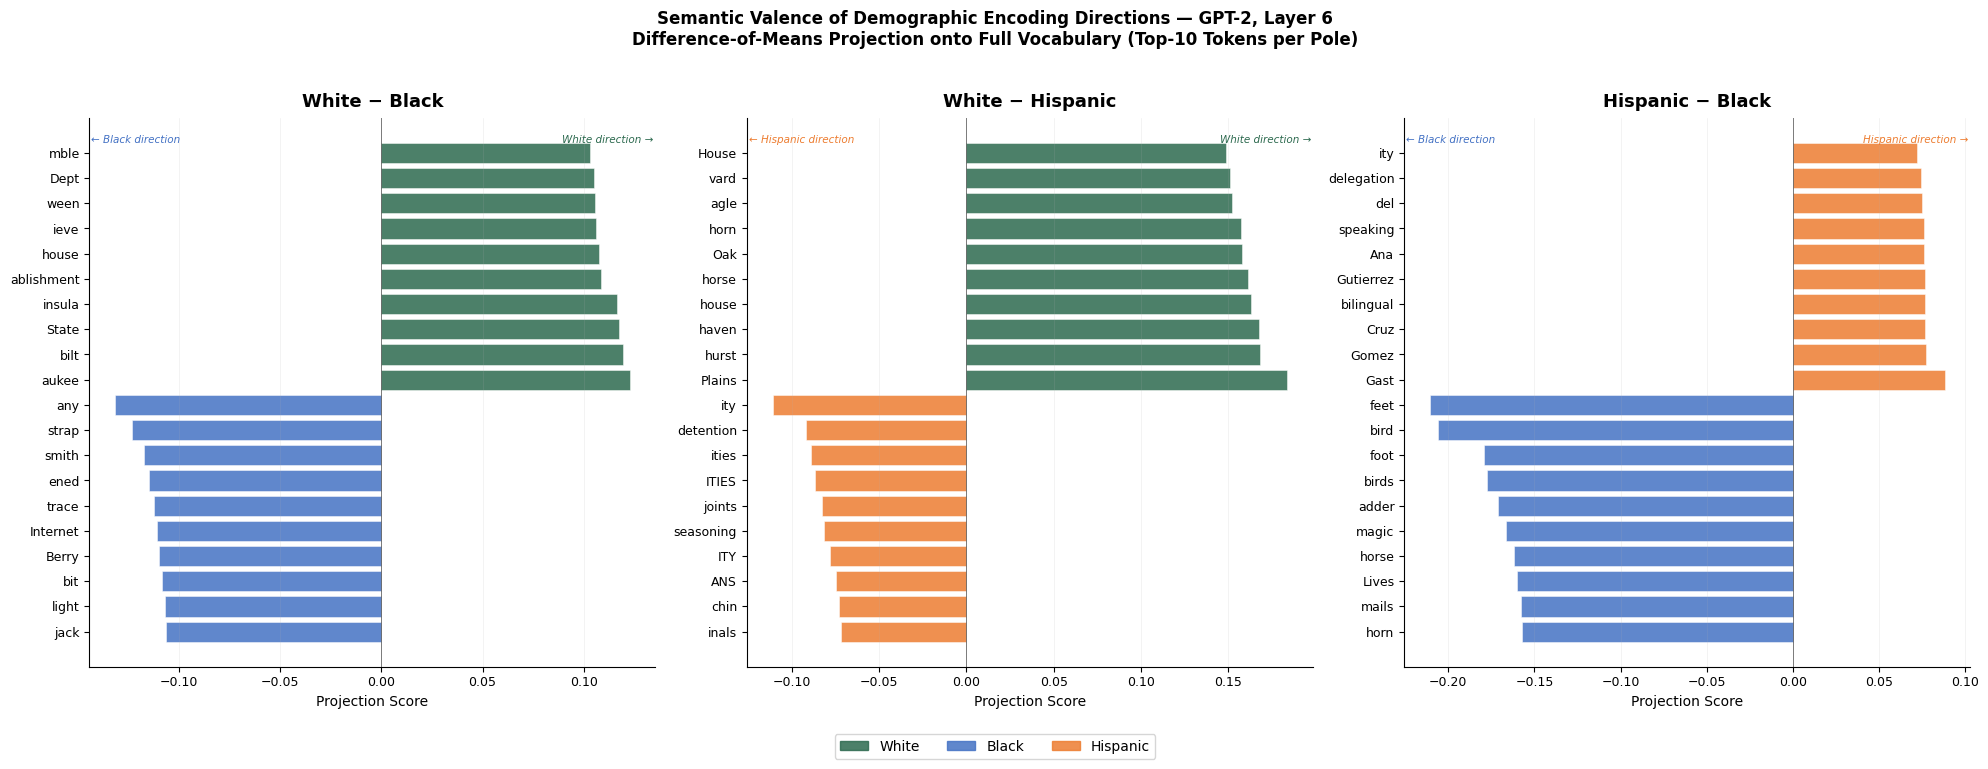

In [9]:
# Cell 9 — figure: three-panel valence comparison at layer 6
# One column per direction, showing both poles

COLORS = {
    'White':    '#2D6A4F',
    'Black':    '#4472C4',
    'Hispanic': '#ED7D31',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
fig.suptitle(
    'Semantic Valence of Demographic Encoding Directions — GPT-2, Layer 6\n'
    'Difference-of-Means Projection onto Full Vocabulary (Top-10 Tokens per Pole)',
    fontsize=12, fontweight='bold', y=1.02
)

direction_configs = [
    ('White_minus_Black',    'White', 'Black',    'White direction \u2192', '\u2190 Black direction'),
    ('White_minus_Hispanic', 'White', 'Hispanic', 'White direction \u2192', '\u2190 Hispanic direction'),
    ('Hispanic_minus_Black', 'Hispanic', 'Black', 'Hispanic direction \u2192', '\u2190 Black direction'),
]

for ax, (dir_name, group_a, group_b, label_a, label_b) in zip(axes, direction_configs):
    layer = 6
    top = valence_results[dir_name][layer]['top']
    bot = valence_results[dir_name][layer]['bottom']

    all_items = list(reversed(bot)) + list(top)
    labels = [t for t, s in all_items]
    scores = [s for t, s in all_items]
    colors = [COLORS[group_b] if s < 0 else COLORS[group_a] for s in scores]

    y_pos = range(len(all_items))
    ax.barh(y_pos, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Projection Score', fontsize=10)
    ax.set_title(f'{group_a} \u2212 {group_b}', fontsize=13, fontweight='bold', pad=8)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='x', alpha=0.2, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xlim = ax.get_xlim()
    ax.text(xlim[0] + 0.001, len(all_items) - 0.3, label_b,
            fontsize=7.5, color=COLORS[group_b], va='top', style='italic')
    ax.text(xlim[1] - 0.001, len(all_items) - 0.3, label_a,
            fontsize=7.5, color=COLORS[group_a], va='top', ha='right', style='italic')

patches = [mpatches.Patch(color=COLORS[g], alpha=0.85, label=g)
           for g in ['White', 'Black', 'Hispanic']]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig_path = f'{OUTPUT_DIR}/white_encoding_valence_layer6.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

Saved: /content/drive/MyDrive/ID-UTH-repo/white_encoding/white_black_valence_by_layer.png


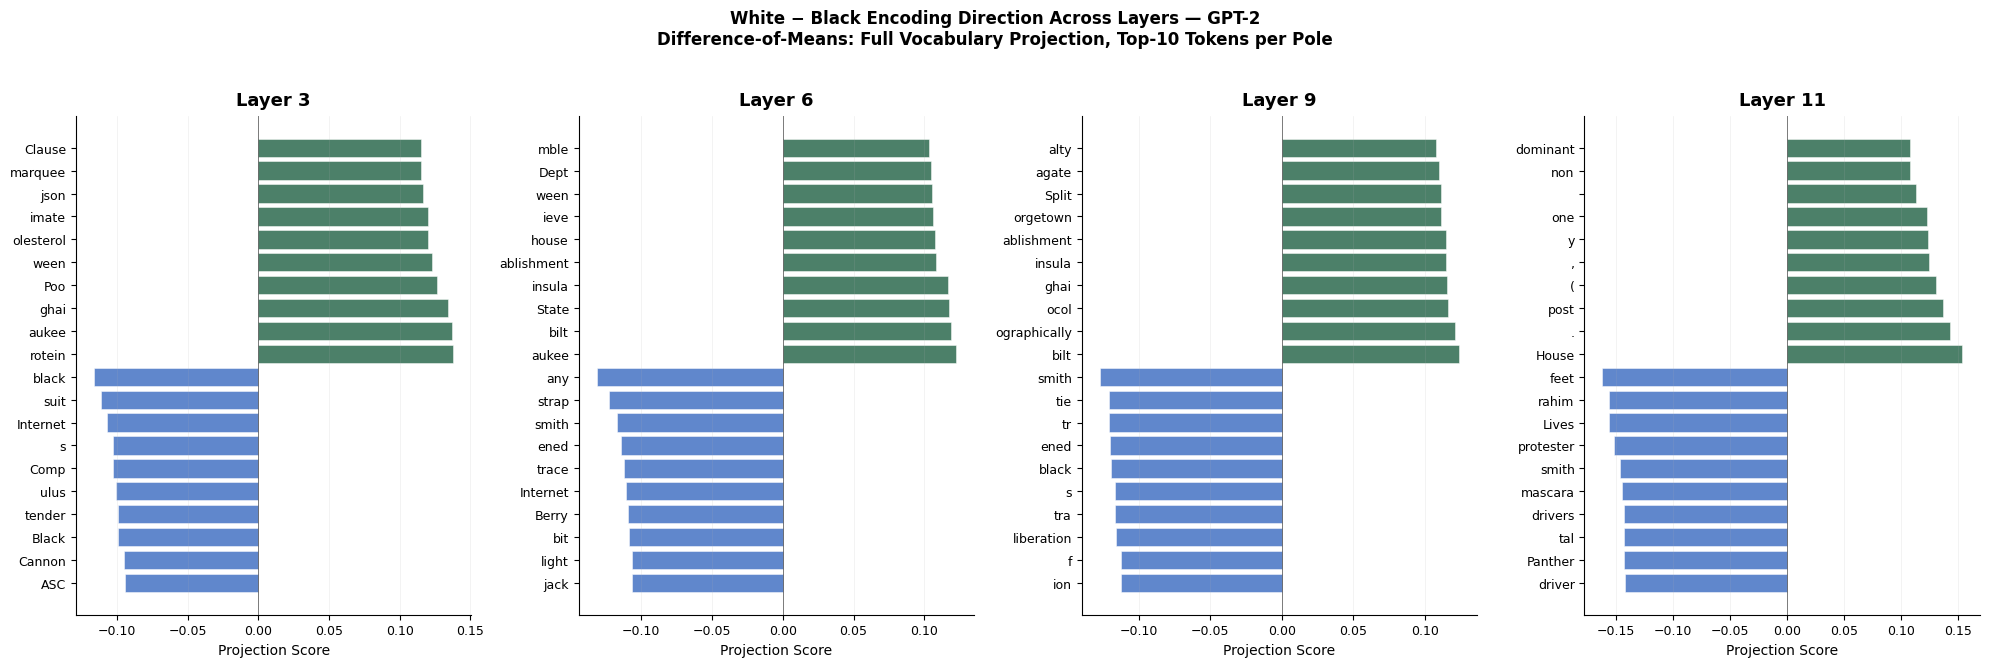

In [10]:
# Cell 10 — layer-by-layer figure for White-Black direction specifically
fig, axes = plt.subplots(1, 4, figsize=(20, 6.5))
fig.suptitle(
    'White \u2212 Black Encoding Direction Across Layers — GPT-2\n'
    'Difference-of-Means: Full Vocabulary Projection, Top-10 Tokens per Pole',
    fontsize=12, fontweight='bold', y=1.02
)

for ax, layer in zip(axes, GPT2_LAYERS):
    top = valence_results['White_minus_Black'][layer]['top']
    bot = valence_results['White_minus_Black'][layer]['bottom']
    all_items = list(reversed(bot)) + list(top)
    labels = [t for t, s in all_items]
    scores = [s for t, s in all_items]
    colors = [COLORS['Black'] if s < 0 else COLORS['White'] for s in scores]

    y_pos = range(len(all_items))
    ax.barh(y_pos, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.7, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Projection Score', fontsize=10)
    ax.set_title(f'Layer {layer}', fontsize=13, fontweight='bold', pad=8)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='x', alpha=0.2, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = f'{OUTPUT_DIR}/white_black_valence_by_layer.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

In [11]:
# Cell 11 — print key findings for paper
print('=' * 65)
print('KEY FINDINGS FOR PAPER')
print('=' * 65)
print()
print('PROBE RESULTS:')
for r in probe_results:
    if r['layer'] == 11:  # peak layer
        print(f"  {r['comparison']}: {r['accuracy']:.1%} ± {r['std']:.1%}")

print()
print('VALENCE LAYER 6 SUMMARY:')
for dir_name, (group_a, group_b) in directions.items():
    top5 = [t for t,s in valence_results[dir_name][6]['top'][:5]]
    bot5 = [t for t,s in valence_results[dir_name][6]['bottom'][:5]]
    print(f'  {group_a} vs {group_b}:')
    print(f'    {group_a} pole: {top5}')
    print(f'    {group_b} pole: {bot5}')
    print()

print('REFERENCE FRAME ANALYSIS:')
print('Is White the implicit reference frame?')
white_black_top = [t for t,s in valence_results['White_minus_Black'][6]['top'][:5]]
white_hisp_top  = [t for t,s in valence_results['White_minus_Hispanic'][6]['top'][:5]]
print(f'  White pole (vs Black):    {white_black_top}')
print(f'  White pole (vs Hispanic): {white_hisp_top}')
print()
print('If White pole tokens are similar across both comparisons,')
print('White may be encoding a stable unmarked reference frame.')
print('If White pole tokens differ substantially,')
print('the encoding is pair-specific rather than reference-frame-based.')

KEY FINDINGS FOR PAPER

PROBE RESULTS:
  White vs Black: 100.0% ± 0.0%
  White vs Hispanic: 100.0% ± 0.0%
  Hispanic vs Black: 100.0% ± 0.0%

VALENCE LAYER 6 SUMMARY:
  White vs Black:
    White pole: ['aukee', 'bilt', 'State', 'insula', 'ablishment']
    Black pole: ['any', 'strap', 'smith', 'ened', 'trace']

  White vs Hispanic:
    White pole: ['Plains', 'hurst', 'haven', 'house', 'horse']
    Hispanic pole: ['ity', 'detention', 'ities', 'ITIES', 'joints']

  Hispanic vs Black:
    Hispanic pole: ['Gast', 'Gomez', 'Cruz', 'bilingual', 'Gutierrez']
    Black pole: ['feet', 'bird', 'foot', 'birds', 'adder']

REFERENCE FRAME ANALYSIS:
Is White the implicit reference frame?
  White pole (vs Black):    ['aukee', 'bilt', 'State', 'insula', 'ablishment']
  White pole (vs Hispanic): ['Plains', 'hurst', 'haven', 'house', 'horse']

If White pole tokens are similar across both comparisons,
White may be encoding a stable unmarked reference frame.
If White pole tokens differ substantially,
the e

In [12]:
# Cell 12 — save results to Drive
import pickle
save_data = {
    'group_records': group_records,
    'probe_results': probe_results,
    'valence_results': {k: {layer: {'top': v['top'], 'bottom': v['bottom']}
                             for layer, v in layers.items()}
                        for k, layers in valence_results.items()}
}
with open(f'{OUTPUT_DIR}/white_encoding_results.pkl', 'wb') as f:
    pickle.dump(save_data, f)

pd.DataFrame(probe_results).to_csv(f'{OUTPUT_DIR}/white_encoding_probe_results.csv', index=False)
print('All results saved to Drive.')
print(f'Folder: {OUTPUT_DIR}')

All results saved to Drive.
Folder: /content/drive/MyDrive/ID-UTH-repo/white_encoding
